In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import numpy as np

import jonswap
import equilibrium

Want to generate equilvalent JONSWAP spectrum given $H_s$, $k_p$ inputs to the Equilibrium spectrum. 

Two ways to approach this:
1. Use the definitions provided by Hasselmann et al. (1973) to convert $k_p$ and $H_s$ into JONSWAP spectrum inputs $U_{10}$ and $X$. This results in a different total energy (i.e., different actual $H_s$).
2. Search for a combination of $U_{10}$ and $X$ inputs to JONSWAP that will match both $k_p$ and total energy $\int\phi(k)dk$ to the desired spectrum.

### functions

Calculate the $H_s$ from total energy in the spectrum according to

$$H_s = 4\sqrt{\int\phi(k)dk}$$

In [2]:
def get_actual_Hs(kp, Hs):
    g = 9.81
    X = 22**6 * 16 * 1.6e-7 / kp**3 / Hs**2
    U10 = np.sqrt(g) / 16 / 1.6e-7 / 22**3 * Hs**2 * kp**(3/2)
    js = jonswap.JONSWAPSpec(X, U10)
    return js.calc_actual_Hs()

Bisection to find necessary $H_s$ input to match desired $H_s$

In [3]:
def bisect_Hs(Hs_actual, kp, min, max, tol=0.001):

    count = 0

    while True:
        mid = (min + max)/2

        Hsmin = get_actual_Hs(kp, min)
        Hsmid = get_actual_Hs(kp, mid)
        Hsmax = get_actual_Hs(kp, max)

        if np.abs(Hsmid - Hs_actual) < tol:
            # print(count, ' iterations')
            # print('mid: {:.2f}, actual: {:.2f}'.format(Hsmid, Hs_actual))
            break

        if np.sign(Hsmax - Hs_actual) == np.sign(Hsmid - Hs_actual):
            max = mid
        elif np.sign(Hsmin - Hs_actual) == np.sign(Hsmid - Hs_actual):
            min = mid
        else:
            raise Exception('no root in range')
        
        count += 1
        
    return mid

In [4]:
def plot_spectra(ax, sp, show_labels=False):
    g = 9.81

    # * Equilibrium spectrum
    eq = equilibrium.EquilibriumSpec(sp['kp'], sp['Hs'], 1e3)

    # * using algorithm (naive Hs)
    Xn = 22**6 * 16 * 1.6e-7 / sp['kp']**3 / sp['Hs']**2
    U10n = np.sqrt(g) / 16 / 1.6e-7 / 22**3 * sp['Hs']**2 * sp['kp']**(3/2)
    js_naive = jonswap.JONSWAPSpec(Xn, U10n)

    # * matching total energy
    # print('bisecting for '+sp['name'])
    Hs_matched = bisect_Hs(sp['Hs'], sp['kp'], sp['Hsmin'], sp['Hsmax'])
    # print('done')
    Xm = 22**6 * 16 * 1.6e-7 / sp['kp']**3 / Hs_matched**2
    U10m = np.sqrt(g) / 16 / 1.6e-7 / 22**3 * Hs_matched**2 * sp['kp']**(3/2)
    js_matched = jonswap.JONSWAPSpec(Xm, U10m)

    # * plot
    kplot = np.logspace(-3,2,1000)
    ls = ['-','--',':']
    labels = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP\nmatched $\\int \\phi(k)\\,dk$']
    color = 'k'

    ax.loglog(kplot, eq.E_k(k=kplot), color=color, ls=ls[0], label=labels[0])
    ax.loglog(kplot, js_naive.E_k(k=kplot), color=color, ls=ls[1], label=labels[1])
    ax.loglog(kplot, js_matched.E_k(k=kplot), color=color, ls=ls[2], label=labels[2])

    ax.set_ylim((1e-5, 2e1))
    ax.set_xlim((1e-2,1e2))
    ax.set_title(sp['name'])

    if show_labels:
        ax.legend()
    



### plot all set of spectra used in the LES comparison study

In [5]:
sp1 = {'name':r'low $H_s$',
       'Hs':0.4, 'kp':0.0785,
       'Hsmin':0.1, 'Hsmax':1.0,
       'color':'#DEA404'}

sp2 = {'name':r'low $k_p$',
       'Hs':1.2, 'kp':0.0393,
       'Hsmin':0.2, 'Hsmax':3.0,
       'color':'#4844CB'}

sp3 = {'name':r'high $H_s$',
       'Hs':2.0, 'kp':0.0785,
       'Hsmin':1.0, 'Hsmax':3.0,
       'color':'#FAE877'}

sp4 = {'name':r'high $k_p$',
       'Hs':1.2, 'kp':0.157,
       'Hsmin':0.5, 'Hsmax':2.0,
       'color':'#9CBCFF'}

spectra = [sp1, sp2, sp3, sp4]

    solved for P = 0.001329 with 32 iterations
    solved for P = 0.004237 with 34 iterations
    solved for P = 0.033229 with 32 iterations
    solved for P = 0.033835 with 31 iterations


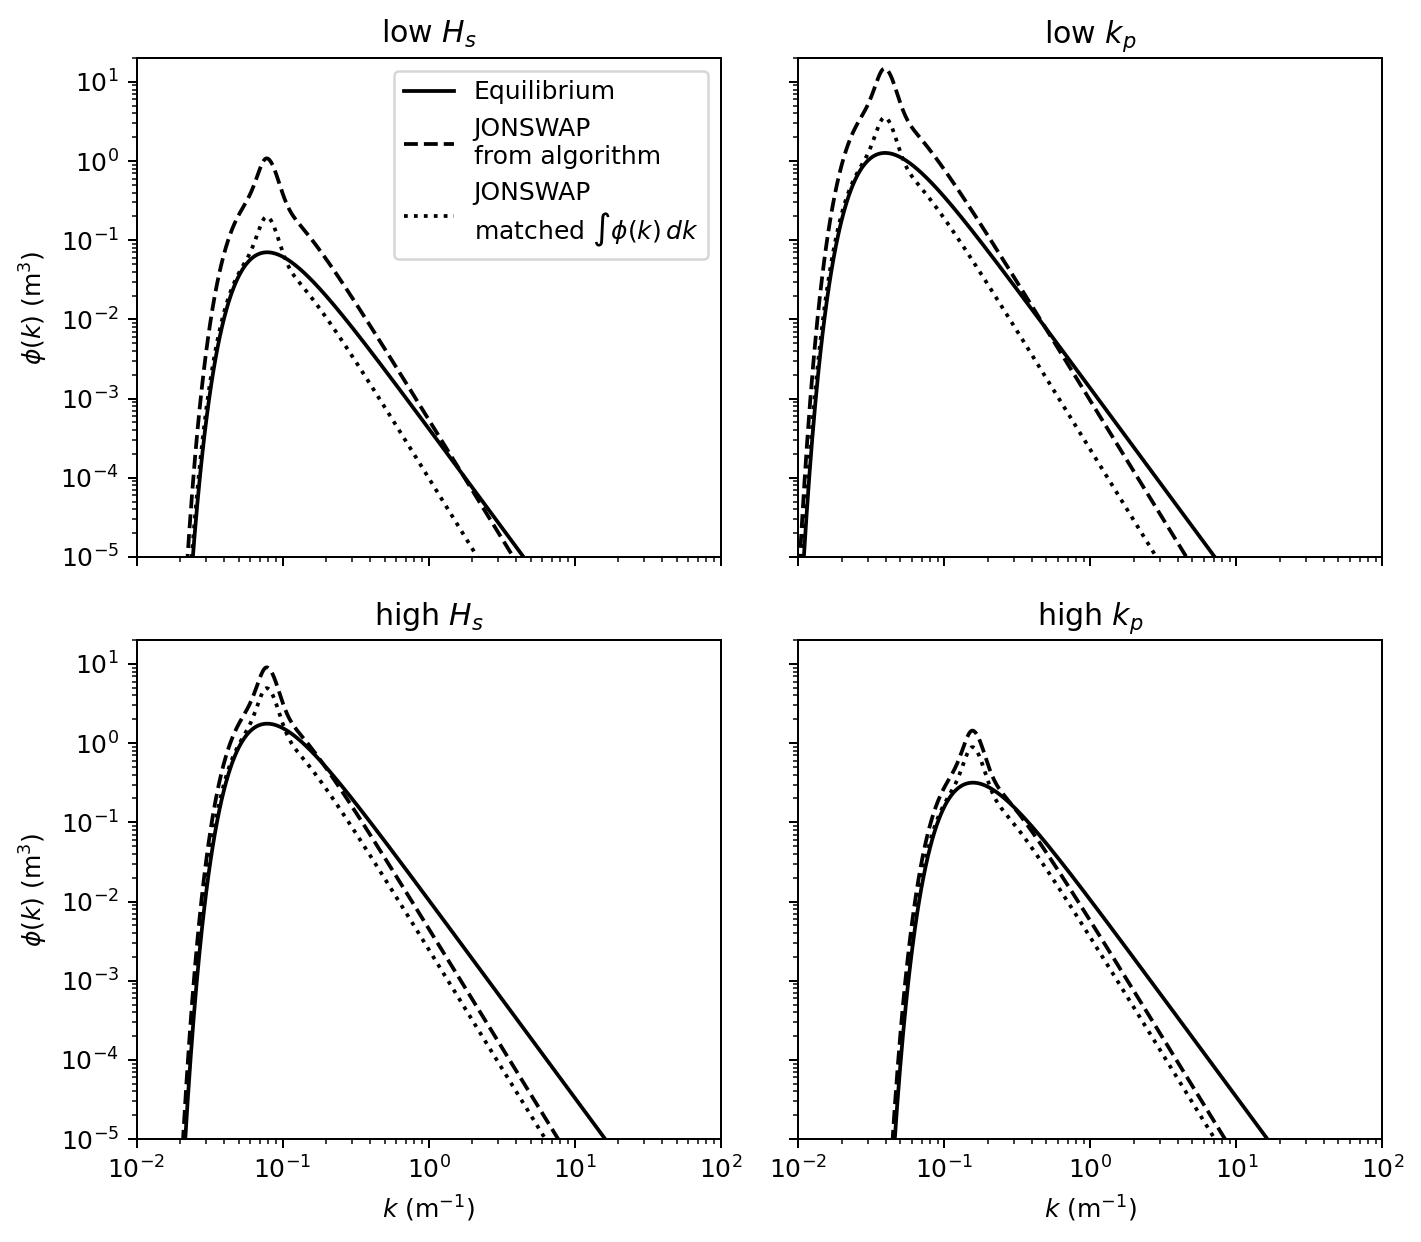

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(8,7), facecolor='white',
                        tight_layout=True, dpi=180, 
                        sharey=True, sharex=True)#, squeeze=True)

axs = np.concatenate([axs[0],axs[1]])

for i in range(len(spectra)):
    if i == 0:
        plot_spectra(axs[i], spectra[i], show_labels=True)
    else:
        plot_spectra(axs[i], spectra[i])

axs[0].set_ylabel(r'$\phi(k)$ (m$^3$)')
axs[2].set_ylabel(r'$\phi(k)$ (m$^3$)')
axs[2].set_xlabel(r'$k$ (m$^{-1}$)')
axs[3].set_xlabel(r'$k$ (m$^{-1}$)')

fig.savefig('figures/les_spectra.pdf')
